# Project 2. Clustering using k-means and k-medoids

### Student ID: 918589943
### Student Name: Chiyang Chen

In [1]:
!pip install basemap

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Union

# Do not use any packages below in your code before part 4

import pandas as pd
from mpl_toolkits.basemap import Basemap # you need to run `pip install basemap` in venv. This will reinstall numpy and some other packages with certain versions 
from pylab import rcParams
from sklearn.preprocessing import StandardScaler

# from sklearn.cluster import KMeans 
# use sklearn to do clustering only if you decide not to get credit from part 1~3

%matplotlib inline

## Outline

In this project, you will 
- I. write a python class to implement the k-means and k-medoids methods, along with a method for comparing clustering results; 
- II. use the python classes you write to do some data analysis with both simulated data and also a real data set.

Note, that one can do the majority of section II without finishing section I by using functions in sklearn, but this automatically leads to zero credit for parts 1-3.

This project is much more challenging and time consuming than the last one. Start early!

## Part 1. Implementing k-means algorithm <font color="red">  </font>

Complete what is missing to implement the k-means algorithm. Read the explicit requirements inside the functions carefully.

In [3]:
class k_means:
    
    def __init__(self, data: np.ndarray, d: int, k: int , tol: float, max_iter: int, seed: int = 20):
        """
        data: data to cluster
        d:dimension of the data
        k: prespecified number of clusters
        tol: convergence criterion
        max_iter: maximum number of iterations allowed
        """
        ### self.partition[i] stores the indices of the points belonging to cluster i
        ### self.labels[i] is the label (ranging from 0-k) for data point i
        
        
        self.data = data
        self.k = k
        self.tol = tol
        self.max_iter = max_iter
        
        self.partitions = {i: [] for i in range(k)}
        self.centers = np.zeros((k, d))
        self.next_centers = np.zeros((k, d))
        self.labels = np.array([])
        self.d = d
        self.n = data.shape[0]
        self.counter = 0
        self.seed = seed
        
        ### suggested number of lines: <= 5
        ### initialize all the necessary variables to store the parameters used in the algorithm
        ### 
        ### your code starts here
        self.cost = np.inf
        ### end of your code
    
    
    def initialize_centers(self, method: int):
        """
        method = 0:
        pick the first k points from the data as centers

        method = 1:
        randomly pick k points from the data as centers
        """
        if method == 0:
            self.centers = self.data[:self.k, :]
    
        elif method == 1:
            np.random.seed(20)
            ### suggested number of lines: = 1
            ### use np.random.choice to initialize the centers;
            
            ### your code starts here
            self.centers = self.data[np.random.choice(self.n, self.k, replace=False), :]
            ### end of your code
        

    def search(self):
        """
        update the partitions and then calculate the next centers; 
        here we use centroids for the k-means method
        """
        self.partitions = {i: [] for i in range(self.k)}
        self.next_centers = np.array([])

        ### suggested number of lines: <= 10
        ### update the self.partitions based on current self.centers;
        ### update the self.next_centers based on self.partitions;
        
        ### your code starts here
        

        for i in range(self.n):
            dist = np.linalg.norm(self.data[i] - self.centers, axis=1)
            cluster = np.argmin(dist)
            self.partitions[cluster].append(i)
        self.next_centers = np.array([self.data[self.partitions[i]].mean(axis=0) for i in range(self.k)])
        
        
        
        ### end of your code
            
            
    def is_updated(self):
        """
        return True if update is completed, meaning that the algorithm has not yet converged; 
        return False otherwise;
        The convergence criterion is the sum of absolute differences between 
        self.centers and self.next_centers being smaller than tol;
        """
        ### suggested number of lines: <= 6
        ### your code starts here

        
        
        if np.sum(np.abs(self.centers - self.next_centers)) < self.tol:
            return False
        return True
        
        
        ### end of your code

        
    def fit_model(self):
        """
        function to fit the k-means algorithms using the above functions
        """
        self.initialize_centers(1)
        self.counter = 0
        
        ### suggested number of lines: <= 15
        ### come up with a control flow to use self.search and self.is_updated to finish the label assignments
        ### print "Maximum Number of Iteration Reached!" if the number of iterations = the maximum iterations allowed
        ### print "Convergence Reached! Number of Iterations: " plus the number of iterations when the label assignment 
        ### has completed by reaching the convergence criterion;
        
        ### your code starts here

        
        
        
        while self.counter < self.max_iter:
            self.search()
            if not self.is_updated():
                print(f'Convergence Reached! Number of Iterations: {self.counter}')
                break
            self.centers = self.next_centers
            self.partitions = {i: [] for i in range(self.k)}
            self.counter += 1
        if self.counter == self.max_iter:
            print('Maximum Number of Iteration Reached!')
        
        
        
        
        ### your code ends here
    
        self.get_labels()

        
    def set_k(self, k: int):
        self.k = k
        
    def predict(self, pt: np.ndarray):
        distances = [np.linalg.norm(pt-c) for c in self.centers]
        cluster_label = distances.index(min(distances))
        return cluster_label

    
    def get_labels(self):
        ### suggested number of lines: <= 6
        ### write an api to update self.labels based on self.partitions
        ### your code starts here
        
        self.labels = np.zeros(self.n) # Reset all labels to a default value

        for i in range(self.k):
            for index in self.partitions[i]:
                self.labels[index] = i
        
        ### end of your code
        
        return self.labels
    
    def get_centers(self):
        return self.centers
    
    def get_clusters(self):
        return self.partitions

    def get_cost(self):
        """
        Here we use within cluster sum of squares as cost 
        """
        ### suggested number of lines: <= 6
        ### write an api to get the cost based on self.partition and self.next_centers (why?)
        ### your code starts here
        

        self.cost = sum([np.sum(np.square(self.data[self.partitions[i]] - self.next_centers[i])) for i in range(self.k)])
        
        
        
        
        ### end of your code
        return self.cost
    
    def plot_clusters(self):
        if self.d > 2:
            print("Dimension too large!")
            return 
        if self.labels.size == 0:
            self.fit_model()
        plt.scatter(self.data[:, 0] , self.data[:, 1], c=self.labels, s=3)
        plt.scatter(np.array(self.centers)[:, 0], np.array(self.centers)[:, 1], marker='*', c=list(range(self.k)), s=300)
        plt.show()


## Part 2. Implementing criteria to evaluate clustering algorithms 

Write a class to implement the clustering evaluation metric "adjusted Rand index". Note that, in contrast to the silhouette score discussed in class, the adjusted Rand index is a measure the is used for *comparing* two clustering results, meaning that we need two sets of clustering labels. So we either have two different clustering methods, or, when running simulations, or using labeled data, we know the set of "true" labels (even though we apply the clustering algorithm without using the labels). In the latter case, we can compare a clustering result with the "truth". To learn about the adjusted Rand index, find more details here: https://en.wikipedia.org/wiki/Rand_index.

In [4]:
class clustering_eval_metrics:
    def __init__(self, labels: np.ndarray, true_labels=None): # label must be between 0 to number_of_labels - 1
        """
        labels: list of labels that are from the clustering algorithm, for example, from the get_labels method in
                the above k_means class
        true_labels: the ground truth of the labels
        """
        self.labels = labels
        self.true_labels = true_labels
        self.cmat = None # this is the contingency table you need to construct
        self.ars = None # this is the adjusted rand score
        
    def set_true_labels(self, true_labels):
        self.true_labels = np.array(true_labels)
    
    def contingency_matrix(self) -> List[List[int]]: 
        """
        return a contingency matrix, that counts n_ij for all i,j
        """
        ### your code starts here
        
        unique_labels = np.unique(self.labels)
        unique_true_labels = np.unique(self.true_labels)
        
        self.cmat = np.zeros((len(unique_labels), len(unique_true_labels)), dtype=int)
        
        for i, label in enumerate(unique_labels):
            for j, true_label in enumerate(unique_true_labels):
                self.cmat[i, j] = np.sum((self.labels == label) & (self.true_labels == true_label))
        
        ### end of your code
        
        return self.cmat
        
    def adjusted_rand_score(self) -> float:
        """
        return the adjusted_rand_score
        """
        ### your code starts here
        if self.cmat is None:
            self.contingency_matrix()
        
        n = np.sum(self.cmat)
        sum_row = np.sum(self.cmat, axis=1)
        sum_col = np.sum(self.cmat, axis=0)

        t1 = np.sum(comb(self.cmat, 2))
        t2 = np.sum(comb(sum_row, 2))
        t3 = np.sum(comb(sum_col, 2))

        expected_index = t2 * t3 / comb(n, 2)
        max_index = 0.5 * (t2 + t3)

        self.ars = (t1 - expected_index) / (max_index - expected_index)

        
        
        ### end of your code

        return self.ars
        

## Part 3. k-medoid algorithm <font color="red">  </font>

Write a class called pam ("pam" stands for "partition around medoids") to implement the k-medoid algorithm. It should have a similar structure as the k_means class as we implemented before. Write the code as concisely as possible. Any code that exceeds 40 lines will get penalized.

In [5]:
class pam(k_means):
    def __init__(self, data: np.ndarray, d: int, k: int , tol: float, max_iter: int, p: float):
        """
        p is the parameter for the L_p norm
        """
        super().__init__(data, d, k, tol, max_iter)
        self.p = p
    ### hint: think about the differences between pam and k_means
    ###       in fact, there are not many, right?
    ### Your code starts here 
    def initialize_medoids(self, method: int):
        if method == 0:
            self.medoids = self.data[:self.k, :]
        elif method == 1:
            np.random.seed(20)
            self.medoids = self.data[np.random.choice(self.n, size=self.k, replace=False), :]  
    
    def search(self):
        self.partitions = {i: [] for i in range(self.k)}
        self.next_medoids = np.empty_like(self.medoids)

        for i in range(self.n):
            distances = [np.linalg.norm(self.data[i] - medoid, ord=self.p) for medoid in self.medoids]
            cluster_index = np.argmin(distances)
            self.partitions[cluster_index].append(i)

        for i in range(self.k):
            if self.partitions[i]:
                self.next_medoids[i] = self.medoid(self.partitions[i])
            else:
                self.next_medoids[i] = self.medoids[i]

    def medoid(self, cluster_indices):
        cluster_data = self.data[cluster_indices]
        distances = np.sum(np.abs(cluster_data - np.median(cluster_data, axis=0)), axis=1)
        medoid_index = np.argmin(distances)
        return cluster_data[medoid_index]

    def is_updated(self):
        return np.any([np.linalg.norm(a - b, ord=self.p) > self.tol for a, b in zip(self.medoids, self.next_medoids)])
        
    def fit_model(self):
        self.initialize_medoids(1) 
        self.counter = 0
    
        while self.counter < self.max_iter:
            self.search()
            
            if not self.is_updated():
                break
                
            self.medoids = self.next_medoids.copy()
            self.counter += 1
        
        if self.counter == self.max_iter:
            print("Maximum Number of Iterations Reached!")
        else:
            print("Convergence Reached! Number of Iterations:", self.counter)
    
        self.get_labels()

    def predict(self, pt: np.ndarray):
        distances = [np.linalg.norm(pt - medoid, ord=self.p) for medoid in self.medoids]
        cluster_label = np.argmin(distances)
        return cluster_label
      
    
    ### your code ends here

## Part 4. Simulation Study  <font color="red">  </font>

### You may choose not to use the functions written above to finish this part. If you choose to use external packages, then you will not earn the points from Part 1~3.

Sample $60$ data points each from the following distributions each

$$ X_1\sim N\bigg(\begin{pmatrix}
0\\
0\end{pmatrix},\begin{pmatrix}
1 & 0\\
0 & 1 \end{pmatrix}\bigg),X_2\sim N\bigg(\begin{pmatrix}
3\\
2\end{pmatrix},\begin{pmatrix}
2 & 1\\
1 & 1 \end{pmatrix}\bigg)
, X_3\sim N\bigg(\begin{pmatrix}
5\\
0\end{pmatrix},\begin{pmatrix}
2 & 1\\
1 & 1 \end{pmatrix}\bigg) $$

and then concatenate these points sequentially to form a sample of size $180$.  Use `np.random.multivariate_normal()` and set `np.random.seed(20)` right before you call `np.random.multivariate_normal()` each time.

In [6]:
data = np.zeros((180, 2))
true_labels = np.zeros(180)

### store your simulated data in data;
### store the labels 0-2 in true_labels;

### your code starts here

np.random.seed(20)
# Generate data for each cluster
data1 = np.random.multivariate_normal([0, 0], [[1, 0], [0, 1]], 60)
np.random.seed(20)
data2 = np.random.multivariate_normal([3, 2], [[2, 1], [1, 1]], 60)
np.random.seed(20)
data3 = np.random.multivariate_normal([5, 0], [[2, 1], [1, 1]], 60)

# Concatenate the data and generate labels
data = np.concatenate((data1, data2, data3), axis=0)
true_labels = np.concatenate((np.zeros(60), np.ones(60), 2*np.ones(60)))



### your code ends here

np.random.seed(20)
ind = np.arange(180)
np.random.shuffle(ind)
data = data[ind]
true_labels = true_labels[ind]

### <font color="Red"> Run the following code.</font> (do not change the code!)

In [7]:
ref_data = np.genfromtxt('./ref_data/part4_sim.csv', delimiter=',')
ref_labels = np.genfromtxt('./ref_data/part4_sim_labels.csv', delimiter=',').astype(np.int32)
ref_cluster = np.genfromtxt('./ref_data/part4_sim_clusters.csv', delimiter=',')
ref_ari_score = np.genfromtxt('./ref_data/part4_sim_ari.csv', delimiter = ',')

### The following lines are to check if you have simulated the data correctly

In [8]:
np.testing.assert_array_equal(true_labels, ref_labels)

In [9]:
np.testing.assert_allclose(data, ref_data, rtol=1e-12)

### 4.1 Apply k-means (with k=3, d=2, tol = 1e-7, max_iter = 500) to the simulated data set. Plot different clusters and their centers, use the `plot_clusters()` API in the k_means class. Also calculate the adjusted rand score.

In [10]:
data = ref_data
true_labels = ref_labels

Convergence Reached! Number of Iterations: 5


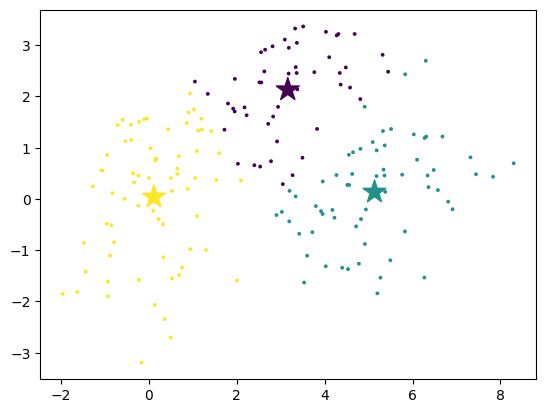

Adjusted Rand Score: 0.7828764282595638


In [11]:
### default value

km = None
ari_score = None

### km is the k_means class object that you create using data;
### ari_score is the ari score of the predicted labels as compared to the "true labels";

### your code starts here
def plot_clusters(self):
    if self.d > 2:
        print("Dimension too large!")
        return 
    if self.labels.size == 0:
        self.fit_model()
        plt.scatter(self.data[:, 0] , self.data[:, 1], c=self.labels, s=3)
        plt.scatter(np.array(self.centers)[:, 0], np.array(self.centers)[:, 1], marker='*', c=list(range(self.k)), s=300)
        plt.show()


from scipy.special import comb

# Initialize and fit the k-means algorithm
km = k_means(data=data, d=2, k=3, tol=1e-7, max_iter=500)
km.fit_model()

# Create an instance of clustering_eval_metrics class
metrics = clustering_eval_metrics(km.get_labels(), true_labels)

# Calculate the contingency matrix
metrics.contingency_matrix()

# Calculate the Adjusted Rand Score
ari_score = metrics.adjusted_rand_score()

# Plot clusters and their centers
km.plot_clusters()

print(f"Adjusted Rand Score: {ari_score}")







### your code ends here

### <font color="Red"> Run the following code.</font> (do not change the code!)

### The following lines are tests to see whether you implemented the methods correctly

In [12]:
np.testing.assert_array_equal(km.get_labels(), ref_cluster)

In [13]:
clustering_eval_metrics(
    np.array(km.get_labels(), dtype=int), ref_cluster.astype(int)
).adjusted_rand_score()

1.0

In [14]:
assert abs(ari_score - ref_ari_score[0]) < 1e-2

### 4.2a Apply pam method (set k=3, d=2, tol = 1e-7, max_iter = 500) to the simulated data set. Plot different clusters and their centers using the $L_p$ "norm" when p=0.1 and p=2. Also calculate the adjusted rand score.

For p = 0.1

Convergence Reached! Number of Iterations: 2


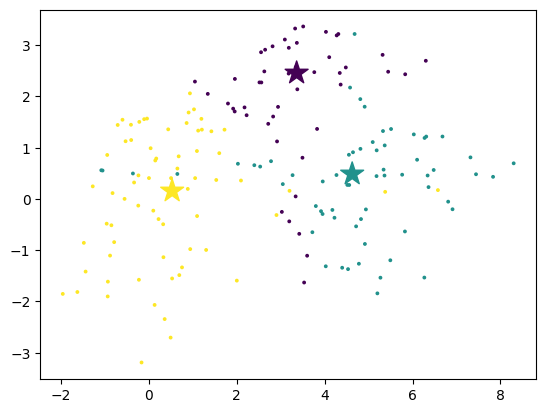

Adjusted Rand Score for p = 0.1: 0.530068701058001


In [15]:
### your code starts here
from sklearn.metrics import adjusted_rand_score

# For p = 0.1
pam_clusterer_01 = pam(data, d=2, k=3, tol=1e-7, max_iter=500, p=0.1)
pam_clusterer_01.fit_model()

# Define a new plot_clusters function
def plot_clusters(data, labels, centers):
    if data.shape[1] > 2:
        print("Dimension too large!")
        return 
    plt.scatter(data[:, 0], data[:, 1], c=labels, s=3)
    plt.scatter(np.array(centers)[:, 0], np.array(centers)[:, 1], marker='*', c=list(range(len(centers))), s=300)
    plt.show()

# Plot the results and calculate the adjusted rand score
labels_01 = pam_clusterer_01.get_labels()
plot_clusters(data, labels_01, centers=pam_clusterer_01.medoids)
print(f"Adjusted Rand Score for p = 0.1: {adjusted_rand_score(true_labels, labels_01)}")





### your code ends here

For p = 2

Convergence Reached! Number of Iterations: 3


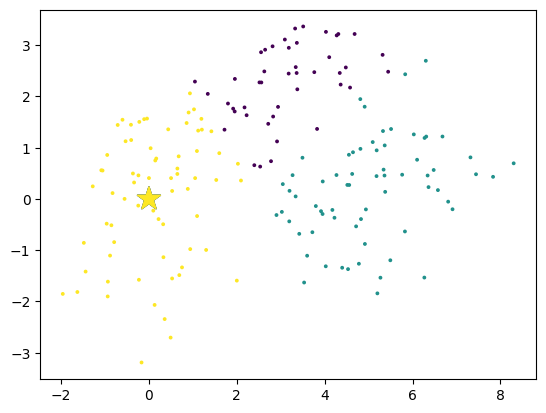

Adjusted Rand Score for p = 2: 0.742948265902021


In [16]:
### your code starts here

pam_clusterer_2 = pam(data, d=2, k=3, tol=1e-7, max_iter=500, p=2)
pam_clusterer_2.fit_model()

# Plot the results and calculate the adjusted rand score
labels_2 = pam_clusterer_2.get_labels()
plt.scatter(data[:, 0], data[:, 1], c=labels_2, s=3)
plt.scatter(np.array(pam_clusterer_2.centers)[:, 0], np.array(pam_clusterer_2.centers)[:, 1], marker='*', c=list(range(pam_clusterer_2.k)), s=300)
plt.show()
print(f"Adjusted Rand Score for p = 2: {adjusted_rand_score(true_labels, labels_2)}")




### your code ends here

### 4.2b Can you compare these two results and analyze quantitatively the cause of the difference?

Hint: The $L_p$ distance $\|x - y\|_p= (|x_1 - y_1|^p + |x_2 - y_2|^p)^{1/p}$ behaves very differently when $p<1.$ (It actually does not even define a metric in this case). You can make a plot of the $L_p$ distance function to illustrate the different behaviors under $p= 0.1$ and $p=2$. We always have 
$$\| x - 0\|_{0.1} = \|x\|_{0.1} \ge \|x\|_2 = \|x - 0\|_2.$$
However, while $\|x\|_{0.1}$ is much larger than $\|x\|_2$ if neither the $x_1$ nor the $x_2$-coordinate are close to 0, $\|x\|_{0.1}$ is quite close to $\|x\|_2$ if one of the coordinates is close to 0.

Suggestion: You can make either one of the following:
+ a scatter plot with grids in range $[-1,1] \times [-1,1]$, and use the color to indicate distance. Use `plt.scatter` and set the color argument `c=distance`.
+ a contour plot with grids in range $[-1,1] \times [-1,1]$, and use `plt.contour` or `plt.contourf`.

You can use `np.meshgrid` to generate 2D grids. See https://np.org/doc/stable/reference/generated/np.meshgrid.html#np.meshgrid


For clarity you can show the colorbar, by `plt.colorbar()`. Besides, you can set the aspect of the plot as 'equal', by `plt.axis('scaled')`.

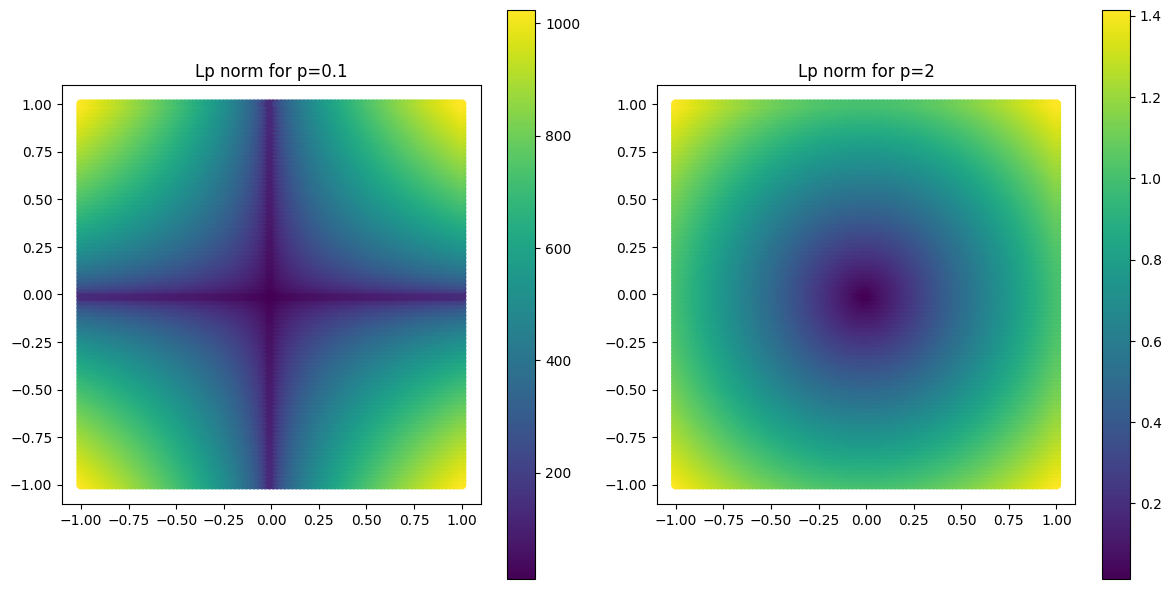

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Generating 2D grids
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
xv, yv = np.meshgrid(x, y)

# Calculating the Lp norm for p=0.1 and p=2
lp_norm_01 = (np.abs(xv)**0.1 + np.abs(yv)**0.1)**(1/0.1)
lp_norm_2 = np.sqrt(xv**2 + yv**2)

# Plotting the scatter plots
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(xv, yv, c=lp_norm_01)
plt.title('Lp norm for p=0.1')
plt.colorbar()
plt.axis('scaled')

plt.subplot(1, 2, 2)
plt.scatter(xv, yv, c=lp_norm_2)
plt.title('Lp norm for p=2')
plt.colorbar()
plt.axis('scaled')

plt.tight_layout()
plt.show()


In the scatter plots, the color represents the $L_p$ norm for a given point. The difference in clustering results for $p=0.1$ and $p=2$ can be attributed to the difference in these norms' behavior. Specifically, for $p=0.1$, the norm is very large if one of the coordinates is close to 0, which shows a cross shape. This may result in different clustering results compared to when using $p=2$, where the norm behaves uniformly around the origin, which shows a round shape.

### 4.2c Are the results from k_means and pam the same when p=2? Why?


No, Adjusted Rand Score for p = 2 GAM: 0.742948265902021,\
while Adjusted Rand Score for p = 2 k-means: 0.7828764282595638

In general, k-means and PAM produce different clustering results because although they both try to minimize the distance from the points within each cluster to the cluster center, PAM uses the data points as the cluster centers, while k-means uses the mean of the clusters. We can see this from the different ari at the same time of p=2. Even though the calculation for norm is both Euclidean distance, the difference between Algorithm implementation caused the final difference. 

### 4.3 How to choose k? First interpret the plot that you get from the code below, then come up with a procedure using this plot to find a k. What k you would like to use? Explain why. 

Hint: make a plot of within cluster sum of square and then use the elbow method.

Convergence Reached! Number of Iterations: 1
Convergence Reached! Number of Iterations: 9
Convergence Reached! Number of Iterations: 9
Convergence Reached! Number of Iterations: 7
Convergence Reached! Number of Iterations: 7
Convergence Reached! Number of Iterations: 10
Convergence Reached! Number of Iterations: 9
Convergence Reached! Number of Iterations: 7
Convergence Reached! Number of Iterations: 7
Convergence Reached! Number of Iterations: 19


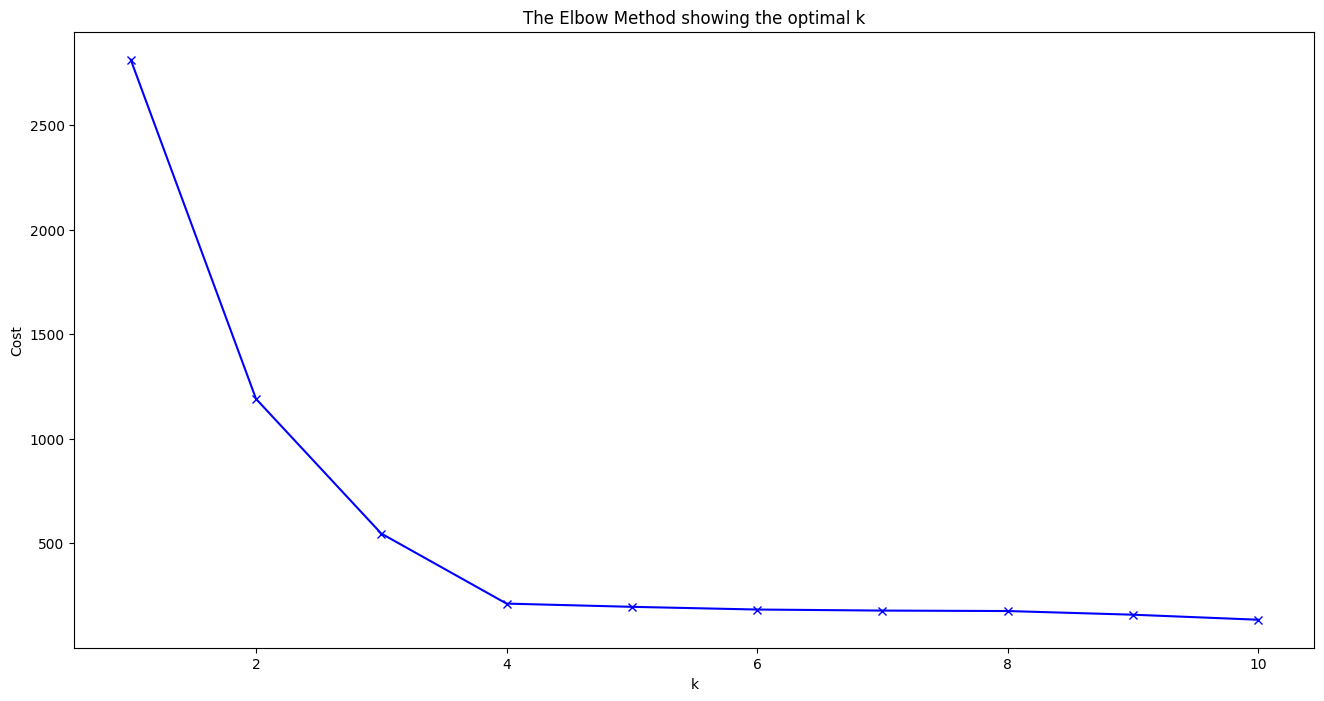

In [18]:
from sklearn.datasets import make_blobs

# Generate a dataset
data, true_labels = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

costs = []
K = range(1,11)
for k in K:
    kmeanModel = k_means(data, d=2, k=k , tol=1e-4, max_iter=300)
    kmeanModel.fit_model()
    costs.append(kmeanModel.get_cost())

# Plot the elbow
plt.figure(figsize=(16,8))
plt.plot(K, costs, 'bx-')
plt.xlabel('k')
plt.ylabel('Cost')
plt.title('The Elbow Method showing the optimal k')
plt.show()


The optimal k should be 4 since a clear turn is observed when K = 4.

## Part 5. Segmentation Analysis <font color="red">  </font>


### About the dataset

The dataset contains the station location and many different weather features observed at each location.
		
<h4 align = "center">
Environment Canada    
Monthly Values for July - 2015	
</h4>
<html>
<head>
<style>
table {
    font-family: arial, sans-serif;
    border-collapse: collapse;
    width: 100%;
}

td, th {
    border: 1px solid #dddddd;
    text-align: left;
    padding: 8px;
}

tr:nth-child(even) {
    background-color: #dddddd;
}
</style>
</head>
<body>

<table>
  <tr>
    <th>Name in the table</th>
    <th>Meaning</th>
  </tr>
  <tr>
    <td><font color = "green"><strong>Stn_Name</font></td>
    <td><font color = "green"><strong>Station Name</font</td>
  </tr>
  <tr>
    <td><font color = "green"><strong>Lat</font></td>
    <td><font color = "green"><strong>Latitude (North+, degrees)</font></td>
  </tr>
  <tr>
    <td><font color = "green"><strong>Long</font></td>
    <td><font color = "green"><strong>Longitude (West - , degrees)</font></td>
  </tr>
  <tr>
    <td>Prov</td>
    <td>Province</td>
  </tr>
  <tr>
    <td>Tm</td>
    <td>Mean Temperature (°C)</td>
  </tr>
  <tr>
    <td>DwTm</td>
    <td>Days without Valid Mean Temperature</td>
  </tr>
  <tr>
    <td>D</td>
    <td>Mean Temperature difference from Normal (1981-2010) (°C)</td>
  </tr>
  <tr>
    <td><font color = "black">Tx</font></td>
    <td><font color = "black">Highest Monthly Maximum Temperature (°C)</font></td>
  </tr>
  <tr>
    <td>DwTx</td>
    <td>Days without Valid Maximum Temperature</td>
  </tr>
  <tr>
    <td><font color = "black">Tn</font></td>
    <td><font color = "black">Lowest Monthly Minimum Temperature (°C)</font></td>
  </tr>
  <tr>
    <td>DwTn</td>
    <td>Days without Valid Minimum Temperature</td>
  </tr>
  <tr>
    <td>S</td>
    <td>Snowfall (cm)</td>
  </tr>
  <tr>
    <td>DwS</td>
    <td>Days without Valid Snowfall</td>
  </tr>
  <tr>
    <td>S%N</td>
    <td>Percent of Normal (1981-2010) Snowfall</td>
  </tr>
  <tr>
    <td><font color = "green"><strong>P</font></td>
    <td><font color = "green"><strong>Total Precipitation (mm)</font></td>
  </tr>
  <tr>
    <td>DwP</td>
    <td>Days without Valid Precipitation</td>
  </tr>
  <tr>
    <td>P%N</td>
    <td>Percent of Normal (1981-2010) Precipitation</td>
  </tr>
  <tr>
    <td>S_G</td>
    <td>Snow on the ground at the end of the month (cm)</td>
  </tr>
  <tr>
    <td>Pd</td>
    <td>Number of days with Precipitation 1.0 mm or more</td>
  </tr>
  <tr>
    <td>BS</td>
    <td>Bright Sunshine (hours)</td>
  </tr>
  <tr>
    <td>DwBS</td>
    <td>Days without Valid Bright Sunshine</td>
  </tr>
  <tr>
    <td>BS%</td>
    <td>Percent of Normal (1981-2010) Bright Sunshine</td>
  </tr>
  <tr>
    <td>HDD</td>
    <td>Degree Days below 18 °C</td>
  </tr>
  <tr>
    <td>CDD</td>
    <td>Degree Days above 18 °C</td>
  </tr>
  <tr>
    <td>Stn_No</td>
    <td>Climate station identifier (first 3 digits indicate   drainage basin, last 4 characters are for sorting alphabetically).</td>
  </tr>
  <tr>
    <td>NA</td>
    <td>Not Available</td>
  </tr>


</table>

</body>
</html>

 

In [19]:
filename = "weather.csv"
df = pd.read_csv(filename)
df = df[pd.notnull(df["Tm"])]
df = df.reset_index(drop=True)
df.head(5)

,Stn_Name,Lat,Long,Prov,Tm,DwTm,D,Tx,DwTx,Tn,...,DwP,P%N,S_G,Pd,BS,DwBS,BS%,HDD,CDD,Stn_No
0,CHEMAINUS,48.935,-123.742,BC,8.2,0.0,NaN,13.5,0.0,1.0,...,0.0,NaN,0.0,12.0,NaN,NaN,NaN,273.3,0.0,1011500
1,COWICHAN LAKE FORESTRY,48.824,-124.133,BC,7.0,0.0,3.0,15.0,0.0,-3.0,...,0.0,104.0,0.0,12.0,NaN,NaN,NaN,307.0,0.0,1012040
2,LAKE COWICHAN,48.829,-124.052,BC,6.8,13.0,2.8,16.0,9.0,-2.5,...,9.0,NaN,NaN,11.0,NaN,NaN,NaN,168.1,0.0,1012055
3,DUNCAN KELVIN CREEK,48.735,-123.728,BC,7.7,2.0,3.4,14.5,2.0,-1.0,...,2.0,NaN,NaN,11.0,NaN,NaN,NaN,267.7,0.0,1012573
4,ESQUIMALT HARBOUR,48.432,-123.439,BC,8.8,0.0,NaN,13.1,0.0,1.9,...,8.0,NaN,NaN,12.0,NaN,NaN,NaN,258.6,0.0,1012710


### Visualization of the data

Read the code below carefully to learn how to plot location data (longitude and lattitude) on a map. 

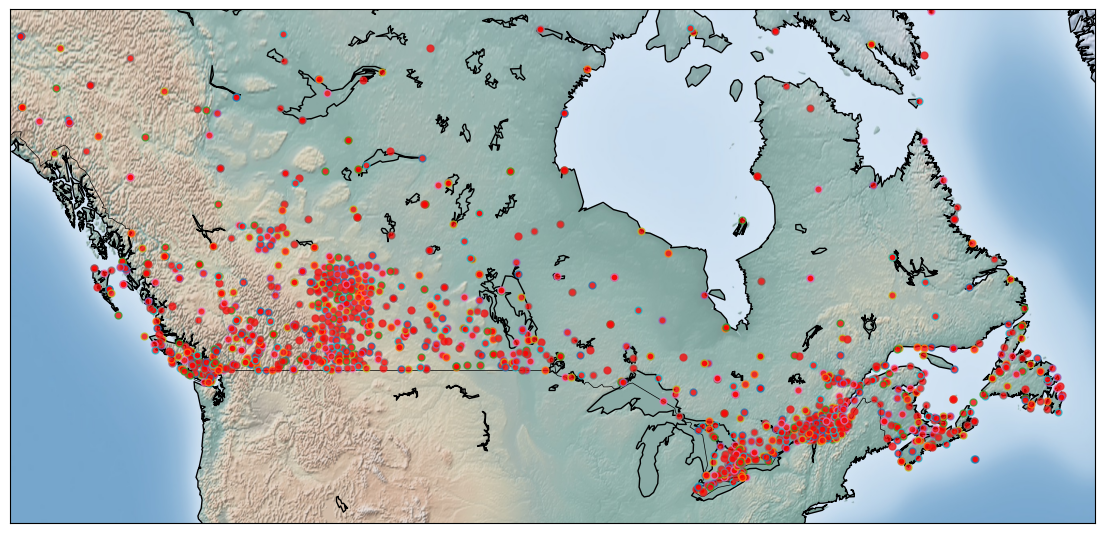

In [20]:
rcParams["figure.figsize"] = (14, 10)
llon = -140
ulon = -50
llat = 40
ulat = 65
df = df[
    (df["Long"] > llon) & (df["Long"] < ulon) & (df["Lat"] > llat) & (df["Lat"] < ulat)
]

my_map = Basemap(
    projection="merc",
    resolution="l",
    area_thresh=1000.0,
    llcrnrlon=llon,
    llcrnrlat=llat,
    urcrnrlon=ulon,
    urcrnrlat=ulat,
)
my_map.drawcoastlines()
my_map.drawcountries()
my_map.shadedrelief()


## this is to change longitude and latitude to coordinates

xs, ys = my_map(np.asarray(df.Long), np.asarray(df.Lat))
df["xm"] = xs.tolist()
df["ym"] = ys.tolist()

# plot the stations on the map
for index, row in df.iterrows():
    my_map.plot(
        row.xm,
        row.ym,
        markerfacecolor=([1, 0, 0]),
        marker="o",
        markersize=5,
        alpha=0.75,
    )
plt.show()

### In the following, you'll work on two datasets data1 (segmentation based on location data only) and data2 (segmentation based on location data as well as the temperature data) to perform k means methods with an appropriate k to do clustering and then label the clusters on two separate maps. 

- You need to justify every decision you make by appropriate plots or reasoning. For example, make a certain plot to explain your decision about which k to use.
- You need to plot the stations on a map, and color them according to their clusters. Also, plot the center of each cluster and label them using their cluster numbers 0,1,...,k-1 as label; use a large enough fontsize (fontsize=25).
- Print out the average temperature of each cluster.

In [21]:
## do not change anything in this block
data1 = df[["xm", "ym"]].to_numpy()
data2 = df[["xm", "ym", "Tx", "Tm", "Tn"]].to_numpy()

data1 = np.nan_to_num(data1)
data1 = StandardScaler().fit_transform(data1)
data2 = np.nan_to_num(data2)
data2 = StandardScaler().fit_transform(data2)

### For data1

1. Use Elbow method to pick a k.

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

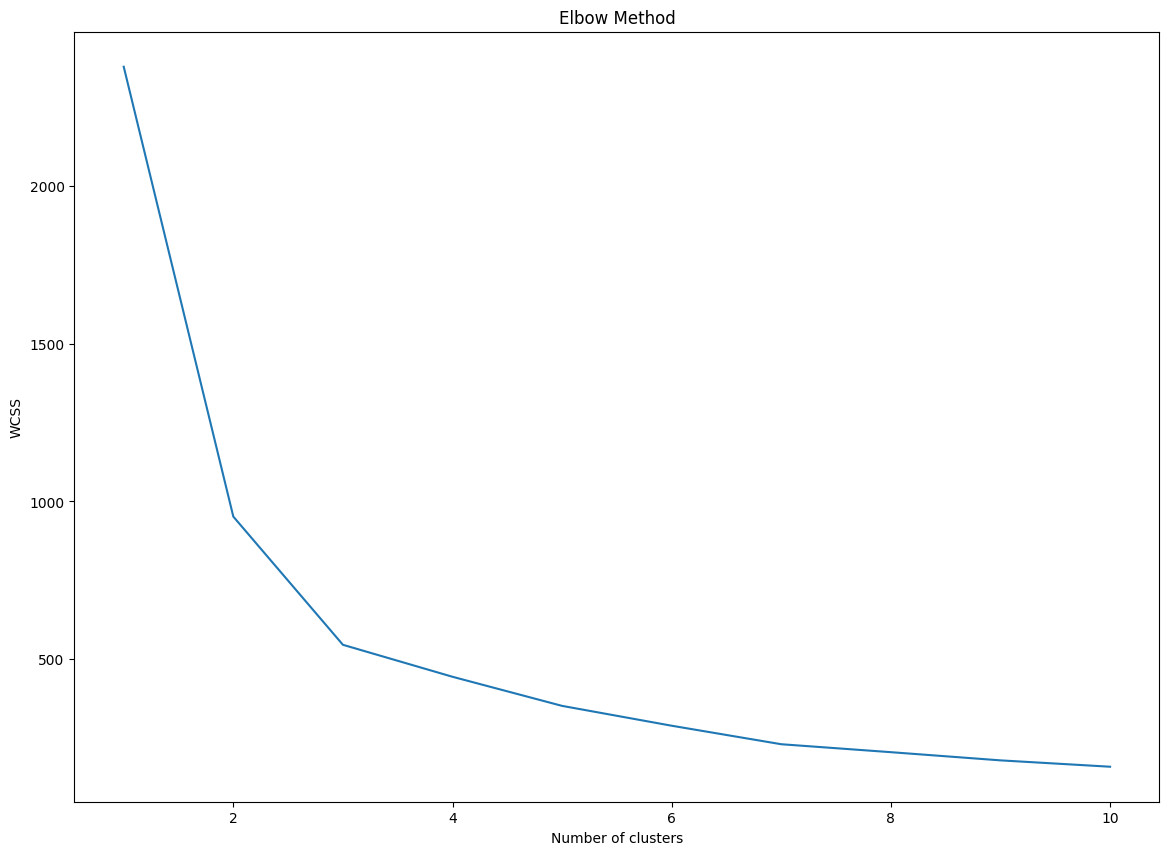

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def compute_elbow(data, max_k):
    wcss = []
    for i in range(1, max_k+1):
        kmeans = KMeans(n_clusters=i, random_state=0)
        kmeans.fit(data)
        wcss.append(kmeans.inertia_)
        
    plt.plot(range(1, max_k+1), wcss)
    plt.title('Elbow Method')
    plt.xlabel('Number of clusters')
    plt.ylabel('WCSS')
    plt.show()

compute_elbow(data1, 10)

2. Fit a k_means model and make the plot on a map.

In [22]:
# Plot k-means clusters for data1 on map
fig = plt.figure(figsize=(14, 10))
llon, ulon, llat, ulat = -140, -50, 40, 65
m = Basemap(projection='merc', llcrnrlat=llat, urcrnrlat=ulat,
            llcrnrlon=llon, urcrnrlon=ulon, lat_ts=20, resolution='l')
m.drawcoastlines()
m.drawcountries()
m.drawstates()

colors = ['red', 'blue', 'green']
for cluster_id in range(k1):
    mask = labels1 == cluster_id
    x, y = m(df['Long'].values[mask], df['Lat'].values[mask])
    m.scatter(x, y, c=colors[cluster_id], label=f'Cluster {cluster_id}', s=30)
    cx, cy = m(df['Long'].values[mask].mean(), df['Lat'].values[mask].mean())
    plt.text(cx, cy, str(cluster_id), fontsize=25, ha='center', va='center',
             color='black', fontweight='bold')

plt.legend()
plt.title('K-Means Clustering of Weather Stations (data1: location only)')
plt.show()

3. Print out the average temperature of each cluster.

In [23]:
k1 = 3
kmeans1 = KMeans(n_clusters=k1, random_state=0)
kmeans1.fit(data1)

labels1 = kmeans1.labels_
centers1 = kmeans1.cluster_centers_

for i in range(k1):
    avg_temp = df.loc[labels1 == i, 'Tm'].mean()
    print(f'Cluster {i} average temperature: {avg_temp}')

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Cluster 0 average temperature: -22.62815533980582
Cluster 1 average temperature: -5.716776315789475
Cluster 2 average temperature: -15.51213389121339


### For data2

1. Use Elbow method to pick a k.

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

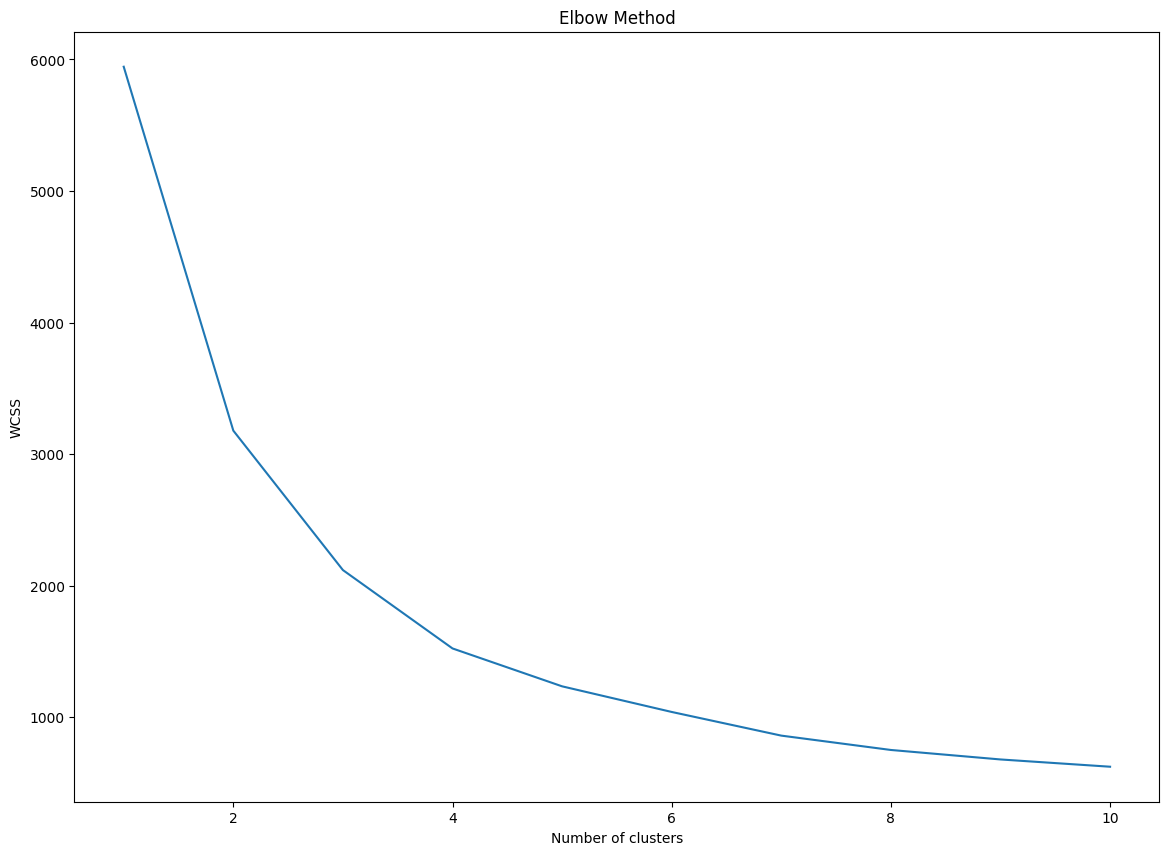

In [24]:
wcss_data2 = compute_elbow(data2, 10)


2. Fit a k_means model and make the plot on a map.

In [24]:
# Plot k-means clusters for data2 on map
k2 = 4
kmeans2 = KMeans(n_clusters=k2, random_state=0)
kmeans2.fit(data2)
labels2 = kmeans2.labels_

fig = plt.figure(figsize=(14, 10))
llon, ulon, llat, ulat = -140, -50, 40, 65
m = Basemap(projection='merc', llcrnrlat=llat, urcrnrlat=ulat,
            llcrnrlon=llon, urcrnrlon=ulon, lat_ts=20, resolution='l')
m.drawcoastlines()
m.drawcountries()
m.drawstates()

colors = ['red', 'blue', 'green', 'orange']
for cluster_id in range(k2):
    mask = labels2 == cluster_id
    x, y = m(df['Long'].values[mask], df['Lat'].values[mask])
    m.scatter(x, y, c=colors[cluster_id], label=f'Cluster {cluster_id}', s=30)
    cx, cy = m(df['Long'].values[mask].mean(), df['Lat'].values[mask].mean())
    plt.text(cx, cy, str(cluster_id), fontsize=25, ha='center', va='center',
             color='black', fontweight='bold')

plt.legend()
plt.title('K-Means Clustering of Weather Stations (data2: location + temperature)')
plt.show()

3. Print out the average temperature of each cluster.

In [25]:
for i in range(k2):
    avg_temp = df.iloc[labels2 == i]['Tm'].mean()
    print(f'Cluster {i} average temperature: {avg_temp}')

Convergence Reached! Number of Iterations: 14
Cluster 0 average temperature: 0.550899885949287
Cluster 1 average temperature: -0.4478706425166059
Cluster 2 average temperature: -1.1734462479051322


## Part 6. (This is question 9 from James et al. 2013, Introduction to Statistical Learning) 
Consider the USArrests data. We will now perform hierarchical clustering on the states.

In [26]:
data_USArrests = pd.read_csv("USArrests.csv")
data_USArrests.rename(columns = {'Unnamed: 0': 'State'}, inplace=True)
data_USArrests.set_index("State", inplace=True)

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

### (a) Using hierarchical clustering with complete linkage (with Euclidean distance), cluster the states. Show different clusters by different colors.

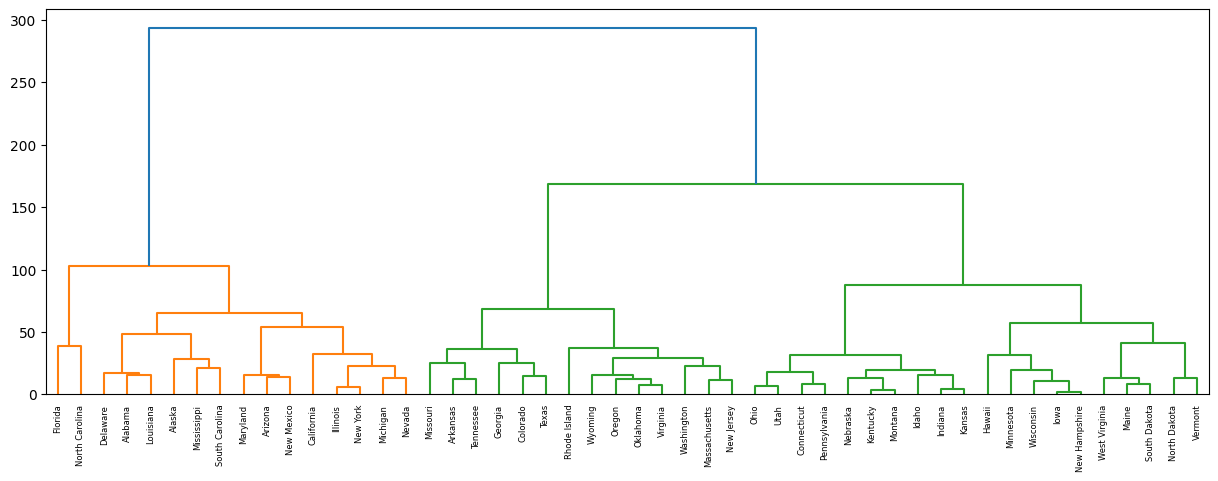

In [27]:
### your code starts here

# Calculate the linkage
mergings = linkage(data_USArrests, method='complete')

# Plot the dendrogram
plt.figure(figsize=(15, 5))
dendrogram(mergings, labels=data_USArrests.index, leaf_rotation=90, leaf_font_size=6)
plt.show()



### (b) Cut the dendrogram at a height that results in three distinct clusters. Which states belong to which clusters?

In [28]:
cluster = AgglomerativeClustering(n_clusters=None, distance_threshold=15, linkage='complete')

# Fit model and predict clusters
data_USArrests['cluster_labels'] = cluster.fit_predict(data_USArrests)

# Check out the states in different clusters
for i in range(3):
    print(f'Cluster {i}:')
    print(data_USArrests[data_USArrests['cluster_labels'] == i].index)

Cluster 0:
Index(['Colorado', 'Texas'], dtype='object', name='State')
Cluster 1:
Index(['Arizona', 'New Mexico'], dtype='object', name='State')
Cluster 2:
Index(['Kentucky', 'Montana', 'Nebraska'], dtype='object', name='State')


#### Which states belong to cluster 0

In [29]:
cluster_states = data_USArrests[data_USArrests['cluster_labels'] == 0].index.tolist()
print(cluster_states)

#### Which states belong to cluster 1

In [30]:
cluster_states = data_USArrests[data_USArrests['cluster_labels'] == 1].index.tolist()
print(cluster_states)

#### Which states belong to cluster 2

In [31]:
cluster_states = data_USArrests[data_USArrests['cluster_labels'] == 2].index.tolist()
print(cluster_states)

('Kentucky', 'Montana', 'Nebraska')

### (c) Hierarchically cluster the states using complete linkage and Euclidean distance, after scaling the variables to have standard deviation one.

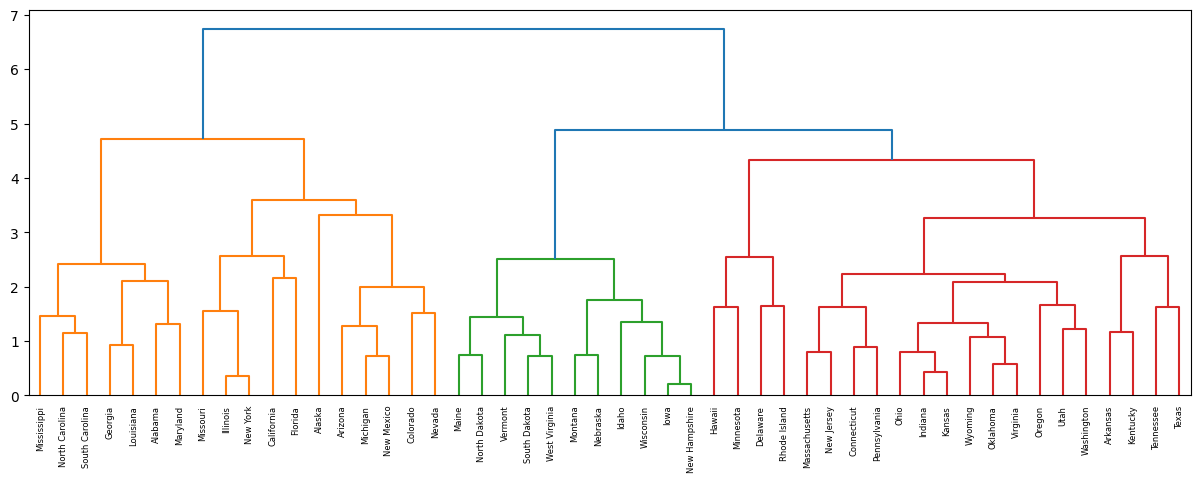

In [32]:
### your code starts here

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_USArrests_scaled = scaler.fit_transform(data_USArrests)
mergings = linkage(data_USArrests_scaled, method='complete')
plt.figure(figsize=(15, 5))
dendrogram(mergings, labels=data_USArrests.index, leaf_rotation=90, leaf_font_size=6)
plt.show()






### (d) What effect does scaling the variables have on the hierarchical clustering obtained? In your opinion, should the variables be scaled before the inter-observation dissimilarities are computed? Provide a justification for your answer.

Variable normalization can have a significant impact on the obtained hierarchical clustering. Since the distributions of our data variables vary widely, this has a greater impact on the distance calculation and thus on the clustering results. By normalizing, we can make all variables equally weighted so that the clustering results are not affected by the original scale. After standardization our clusters become more similar in height, which also reflects more differences in variables.

